# STAC 

In [1]:
# pystac_client = 
    # - Python-Bibliothek zum Abfragen von STAC-APIs (SpatioTemporal Asset Catalog)
    # - "Suchmaschine" für Geodaten: Filter nach Bbox, Zeitraum, Cloud-Cover etc.
    # - liefert Metadaten + Asset-Links zu Satellitenszenen zurueck, kein Download noetig
# planetary_computer
    # - Microsoft-Erweiterung/SDK fuer den Planetary Computer STAC-Katalog
    # - stellt kostenlosen Zugriff auf Sentinel-2 & andere Satellitendaten (Azure Storage) bereit
    # - sign_inplace haengt automatisch ein temporaeres SAS-Token an jede Asset-URL
    #   (Authentifizierung-as-a-Service, ohne eigene Credentials)  

In [2]:
# Sentinel-2 Q4 2020 (Oktober–Dezember) für Sundarbans-Bbox suchen.
# Ziel: wolkenarme Szene mit maximaler Überlappung mit GMW-Mangroven-Polygonen finden.

In [ ]:
import sys; sys.path.insert(0, "..")
import pandas as pd
from src.data_loader import search_sentinel2, rank_by_gmw_overlap, load_sentinel2_bands
from src.analysis import resample_bands, build_feature_stack, rasterize_gmw, draw_balanced_sample

BBOX = (88.0, 21.3, 90.7, 23.0)  # gleiche Bbox wie Notebook 02
items = search_sentinel2(BBOX, "2020-10-01/2020-12-31", cloud_cover_lt=10)
print(f"Gefundene Szenen: {len(items)}")
for item in items:
    print(item.id, "| Cloud Cover:", item.properties["eo:cloud_cover"], "| Datum:", item.datetime.date())

In [4]:
# Schritt 1: nach Cloud Cover sortieren — zeigt aber nur, wie wolkenfrei eine Szene ist.
# Problem: Kachel T46QBJ (Rang 0) liegt im Flussmündungsbereich — keine Mangroven.
# → Cloud Cover allein reicht nicht; nächster Schritt: GMW-Overlap-Ranking.
import pandas as pd

records = [
    {
        "id": item.id,
        "datetime": item.datetime.date(),
        "cloud_cover": item.properties["eo:cloud_cover"],
        "tile": item.properties.get("s2:mgrs_tile"),
    }
    for item in items
]

df_items = pd.DataFrame(records).sort_values("cloud_cover").reset_index(drop=True)
df_items.head(10)

,id,datetime,cloud_cover,tile
0,S2B_MSIL2A_20201127T043129_R133_T46QBJ_2020121...,2020-11-27,0.000007,46QBJ
1,S2B_MSIL2A_20201127T043129_R133_T45QZD_2020121...,2020-11-27,0.000010,45QZD
2,S2B_MSIL2A_20201217T043159_R133_T45QZD_2021010...,2020-12-17,0.000023,45QZD
3,S2B_MSIL2A_20201220T044209_R033_T45QXD_2020122...,2020-12-20,0.000067,45QXD
4,S2B_MSIL2A_20201207T043149_R133_T45QXD_2020120...,2020-12-07,0.000131,45QXD
5,S2B_MSIL2A_20201028T042909_R133_T45QXD_2020110...,2020-10-28,0.000143,45QXD
6,S2B_MSIL2A_20201107T042959_R133_T45QYD_2020110...,2020-11-07,0.000167,45QYD
7,S2B_MSIL2A_20201227T043209_R133_T45QXD_2020122...,2020-12-27,0.000212,45QXD
8,S2B_MSIL2A_20201227T043209_R133_T45QYD_2020122...,2020-12-27,0.000236,45QYD
9,S2B_MSIL2A_20201227T043209_R133_T45QZD_2020122...,2020-12-27,0.000279,45QZD


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

bands = {"B04": "red", "B03": "green", "B02": "blue", "B08": "nir"}

In [6]:
# Was ist NDVI physikalisch? 
# NDVI = (NIR − Red) / (NIR + Red), Wertebereich -1 bis +1. 
# Gesunde Vegetation absorbiert Rotlicht stark (Photosynthese, Chlorophyll) aber 
# reflektiert NIR stark (Zellstruktur der Blätter) → großer Unterschied NIR-Red → 
# hoher NDVI (0.3-0.8+). 
# Wasser absorbiert NIR fast vollständig und reflektiert wenig Rot → NDVI nahe 0 oder
# negativ. 
# Boden/Sand liegt meist dazwischen (0.1-0.3).

In [7]:
# Schritt 2: GMW-Overlap-Ranking — für jede Szene berechnen, wie viel Fläche
# ihr Footprint mit den GMW-Mangroven-Polygonen überlappt (in Grad²).
# Ergebnis: alle Top-10-Szenen sind Kachel T45QYE → deckt den Mangrovenwald ab.

In [ ]:
import geopandas as gpd

# bbox-Parameter liest nur Polygone im Sundarbans-Ausschnitt — statt globale Datei komplett laden
gmw_2020 = gpd.read_file("../data/raw/gmw_v3_2020/gmw_v3_2020_vec.shp", bbox=BBOX)
gmw_union = gmw_2020.union_all()

df_overlap = rank_by_gmw_overlap(items, gmw_union)
df_overlap.head(10)

# Szene auswählen und Bänder laden

In [ ]:
selected_item = next(item for item in items if item.id == df_overlap.loc[7, "id"])
selected_item_id = selected_item.id

print("Szene:", selected_item_id)
print("Cloud Cover:", selected_item.properties["eo:cloud_cover"])
print("Datum:", selected_item.datetime.date())

data = load_sentinel2_bands(selected_item, BBOX, bands)
for name, da in data.items():
    print(name, da.shape)

red = data["red"].values.astype(float)
nir = data["nir"].values.astype(float)
with np.errstate(divide="ignore", invalid="ignore"):
    ndvi = (nir - red) / (nir + red)
print("NDVI mean:", np.nanmean(ndvi))

# True Color (Percentile-Stretch) und NDVI

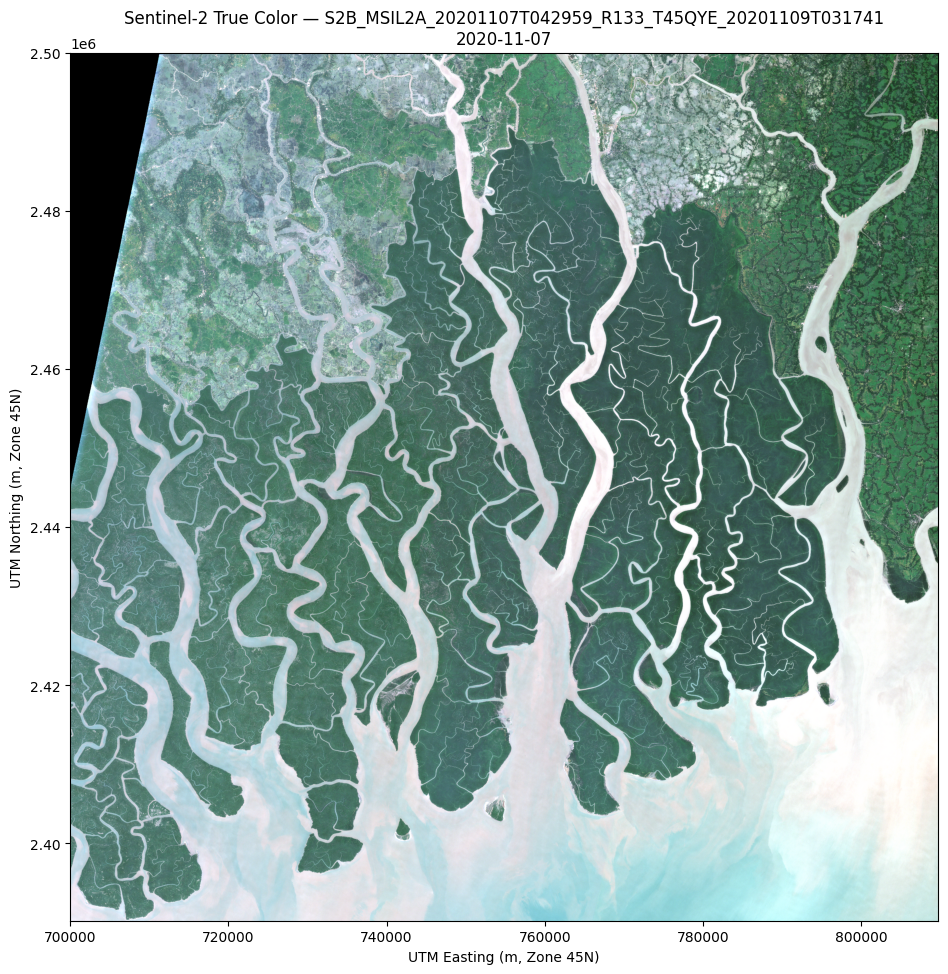

In [10]:
def normalize_pct(band, p_low=2, p_high=98):
    lo, hi = np.percentile(band, [p_low, p_high])
    return np.clip((band - lo) / (hi - lo), 0, 1)

x = data["red"].x.values
y = data["red"].y.values
extent = [x.min(), x.max(), y.min(), y.max()]

# [::4, ::4] = jeden 4. Pixel — 16x weniger Daten im Plot, visuell kein Unterschied
rgb = np.stack([
    normalize_pct(data["red"].values[::4, ::4]),
    normalize_pct(data["green"].values[::4, ::4]),
    normalize_pct(data["blue"].values[::4, ::4]),
], axis=-1)

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(rgb, extent=extent)
ax.set_title(f"Sentinel-2 True Color — {selected_item_id}\n{selected_item.datetime.date()}")
ax.set_xlabel("UTM Easting (m, Zone 45N)")
ax.set_ylabel("UTM Northing (m, Zone 45N)")
plt.tight_layout()
plt.savefig("../assets/screenshots/03-s1_true-color_2026-06-13.png", dpi=150)
plt.show()

NaN-Pixel: 3,130,148 (2.60%)
NDVI min: -0.8198198198198198 max: 0.9994017349685911 mean: 0.3361269535071426


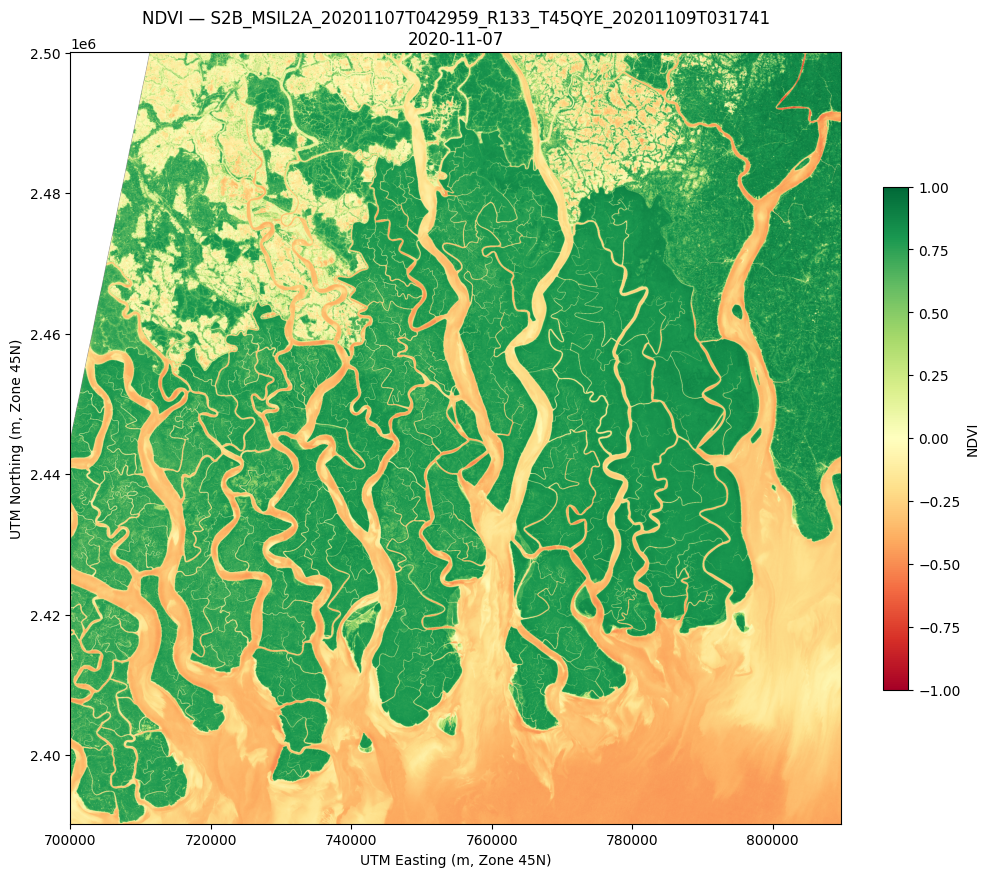

In [11]:
n_nan = np.isnan(ndvi).sum()
print(f"NaN-Pixel: {n_nan:,} ({100*n_nan/ndvi.size:.2f}%)")
print("NDVI min:", np.nanmin(ndvi), "max:", np.nanmax(ndvi), "mean:", np.nanmean(ndvi))

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(ndvi[::4, ::4], cmap="RdYlGn", vmin=-1, vmax=1, extent=extent)
ax.set_title(f"NDVI — {selected_item_id}\n{selected_item.datetime.date()}")
ax.set_xlabel("UTM Easting (m, Zone 45N)")
ax.set_ylabel("UTM Northing (m, Zone 45N)")
plt.colorbar(im, ax=ax, label="NDVI", fraction=0.03)
plt.tight_layout()
plt.savefig("../assets/screenshots/03-s1_ndvi_2026-06-13.png", dpi=150)
plt.show()

# GMW-Overlay: Mangroven-Polygone auf Sentinel-UTM umprojizieren

GMW-Polygone im Ausschnitt: 2073


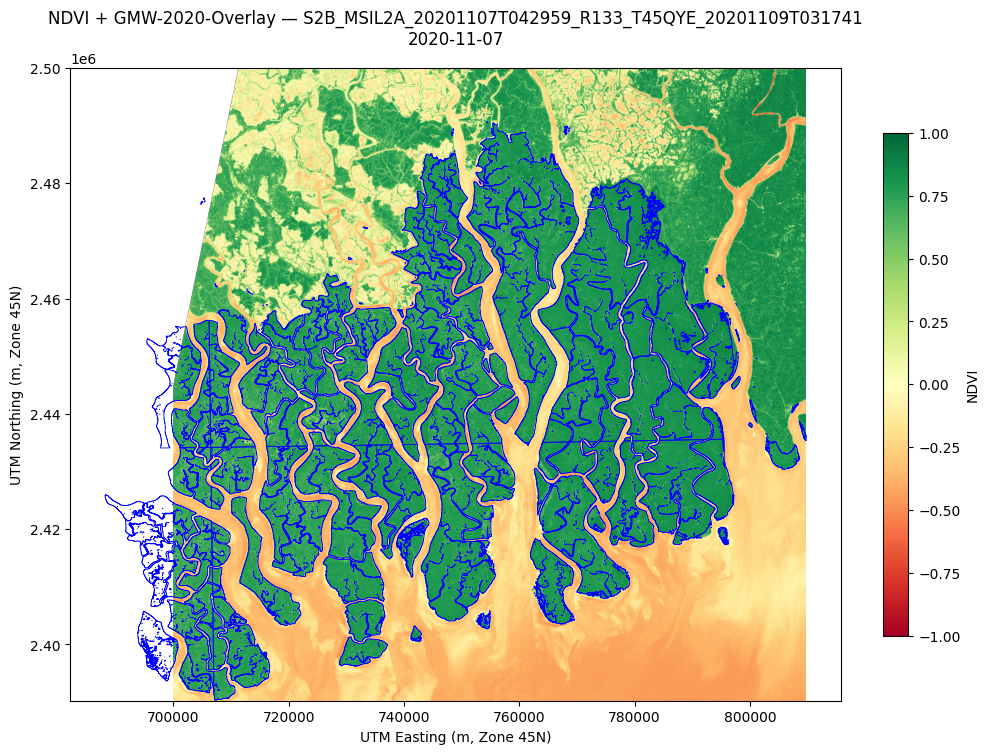

In [12]:
bounds = data["red"].rio.bounds()
gmw_utm = gmw_2020.to_crs(data["red"].rio.crs)
gmw_clip = gmw_utm.cx[bounds[0]:bounds[2], bounds[1]:bounds[3]]

print(f"GMW-Polygone im Ausschnitt: {len(gmw_clip)}")

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(ndvi[::4, ::4], cmap="RdYlGn", vmin=-1, vmax=1, extent=extent)
gmw_clip.boundary.plot(ax=ax, color="blue", linewidth=0.6)
ax.set_title(f"NDVI + GMW-2020-Overlay — {selected_item_id}\n{selected_item.datetime.date()}")
ax.set_xlabel("UTM Easting (m, Zone 45N)")
ax.set_ylabel("UTM Northing (m, Zone 45N)")
plt.colorbar(im, ax=ax, label="NDVI", fraction=0.03)
plt.tight_layout()
plt.savefig("../assets/screenshots/03-s1_ndvi-gmw-overlay_2026-06-13.png", dpi=150)
plt.show()

In [13]:
import pystac_client, planetary_computer, rioxarray, numpy as np, geopandas as gpd
import matplotlib.pyplot as plt
from rasterio.features import rasterize
from rasterio.transform import from_bounds

# STAC-Katalog öffnen (sign_inplace hängt automatisch SAS-Tokens an alle Asset-URLs)
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)
BBOX = (88.0, 21.3, 90.7, 23.0)

# Sentinel-2-Szenen für Sundarbans-Bbox, Q1 2020, Cloud Cover < 10% suchen
search = catalog.search(
    collections=["sentinel-2-l2a"], bbox=BBOX,
    datetime="2020-01-01/2020-03-31",
    query={"eo:cloud_cover": {"lt": 10}},
)
items = list(search.items())

In [ ]:
# Sentinel-2 liefert B02/B03/B04/B08 nativ auf 10 m. Die Konvention schreibt 20 m vor, weil das den Speicher
# viertelt und für Random Forest vollkommen ausreicht — der Classifier braucht keine Sub-Pixel-Genauigkeit.

TARGET_RES = 20  # Meter, Konvention aus PROJEKT_KONVENTIONEN.md
bands_20m = resample_bands(data, TARGET_RES)

ref = bands_20m["red"]
print(f"Neue Shape: {ref.shape}")
print(f"Auflösung: {ref.rio.resolution()}")
print(f"CRS: {ref.rio.crs}")

In [ ]:
stack = build_feature_stack(bands_20m)

print(f"Stack shape: {stack.shape}")
print(f"NaN-Pixel (irgendein Band): {np.isnan(stack).any(axis=0).sum():,}")

In [ ]:
label_mask = rasterize_gmw(gmw_2020, bands_20m["red"])

print(f"Label-Maske shape: {label_mask.shape}")
print(f"Mangrove-Pixel (1): {label_mask.sum():,}")
print(f"Non-Mangrove-Pixel (0): {(label_mask == 0).sum():,}")
print(f"Mangrove-Anteil: {label_mask.mean()*100:.1f}%")

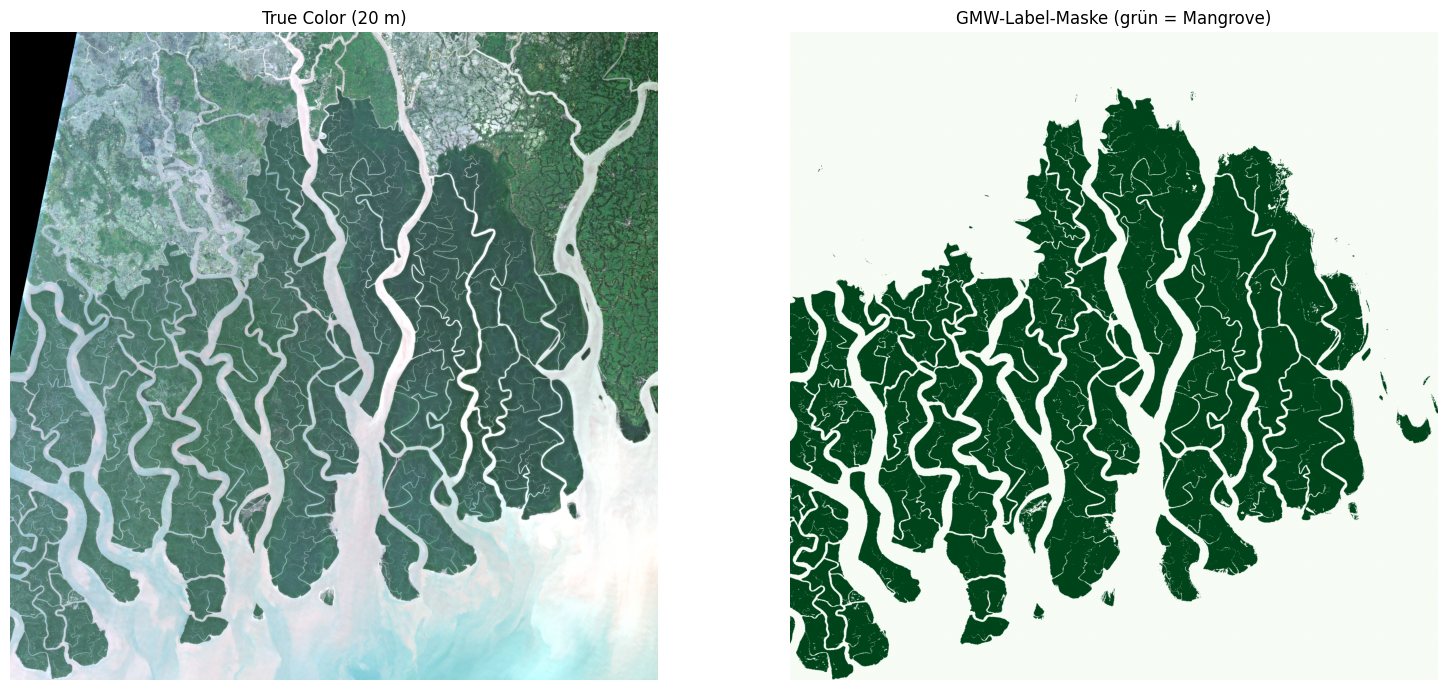

In [20]:
# ── Screenshot 5: Label-Maske neben True Color ───────────────────────────────
def normalize_pct(arr, p1=2, p2=98):
    lo, hi = np.nanpercentile(arr, [p1, p2])
    return np.clip((arr - lo) / (hi - lo), 0, 1)

rgb = np.stack([
    normalize_pct(bands_20m["red"].values),
    normalize_pct(bands_20m["green"].values),
    normalize_pct(bands_20m["blue"].values),
], axis=-1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
ax1.imshow(rgb[::2, ::2])
ax1.set_title("True Color (20 m)")
ax1.axis("off")

ax2.imshow(label_mask[::2, ::2], cmap="Greens", vmin=0, vmax=1)
ax2.set_title("GMW-Label-Maske (grün = Mangrove)")
ax2.axis("off")

plt.tight_layout()
plt.savefig("../assets/screenshots/03-s2_label-mask_2026-07-12.png", dpi=150)
plt.show()

In [ ]:
X_train, y_train = draw_balanced_sample(stack, label_mask, n_per_class=50_000)

print(f"X_train: {X_train.shape}")
print(f"Klasse 0: {(y_train==0).sum():,}  |  Klasse 1: {(y_train==1).sum():,}")

In [39]:
# ── S6: Random Forest trainieren ─────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=15,
    n_jobs=-1,
    class_weight="balanced",
    random_state=42,
)
rf.fit(X_tr, y_tr)

from sklearn.metrics import classification_report
print(classification_report(y_val, rf.predict(X_val),
      target_names=["Non-Mangrove", "Mangrove"]))

              precision    recall  f1-score   support

Non-Mangrove       0.94      0.91      0.92     10000
    Mangrove       0.91      0.94      0.92     10000

    accuracy                           0.92     20000
   macro avg       0.92      0.92      0.92     20000
weighted avg       0.92      0.92      0.92     20000



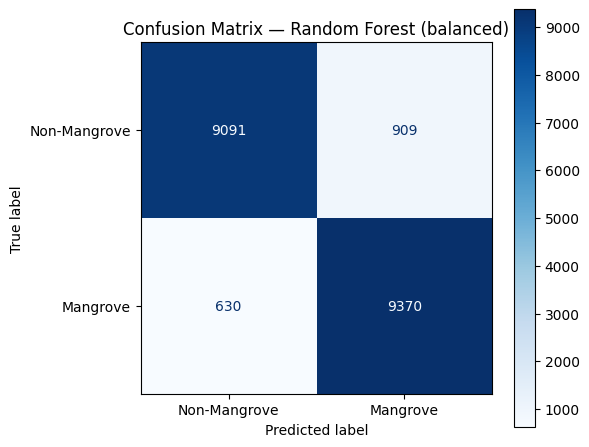

In [40]:
# ── Screenshot 6: Confusion Matrix ───────────────────────────────────────────
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val, rf.predict(X_val),
    display_labels=["Non-Mangrove", "Mangrove"],
    cmap="Blues",
    ax=ax,
)
ax.set_title("Confusion Matrix — Random Forest (balanced)")
plt.tight_layout()
plt.savefig("../assets/screenshots/03-s2_confusion-matrix_2026-07-12.png", dpi=150)
plt.show()

In [ ]:
X_all     = stack.reshape(5, -1).T              # (30_140_100, 5) — mit NaN
valid_all = ~np.isnan(X_all).any(axis=1)        # (30_140_100,)

pred_full = np.full(X_all.shape[0], 255, dtype="uint8")
pred_full[valid_all] = rf.predict(X_all[valid_all])

pred_map = pred_full.reshape(5490, 5490)
pred_map_plot = pred_map.astype(float)
pred_map_plot[pred_map == 255] = np.nan

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(pred_map_plot, cmap="Greens", vmin=0, vmax=1)
ax.set_title("RF-Klassifikation — Mangrove (grün) / Non-Mangrove")
ax.axis("off")
plt.tight_layout()
plt.savefig("../assets/screenshots/03-s2_pred-map_2026-07-12.png", dpi=150)
plt.show()

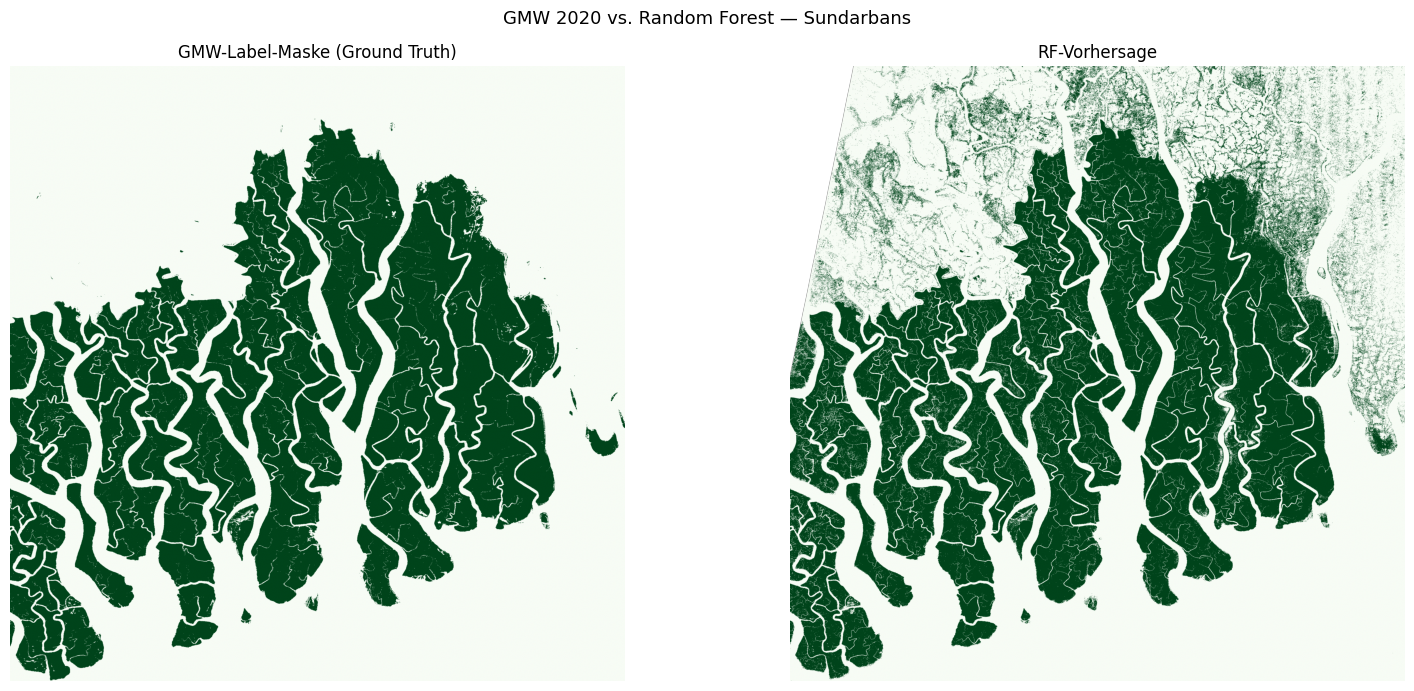

In [42]:
# ── Screenshot 8: GMW-Maske vs. RF-Vorhersage ────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

ax1.imshow(label_mask[::2, ::2], cmap="Greens", vmin=0, vmax=1)
ax1.set_title("GMW-Label-Maske (Ground Truth)")
ax1.axis("off")

ax2.imshow(pred_map_plot[::2, ::2], cmap="Greens", vmin=0, vmax=1)
ax2.set_title("RF-Vorhersage")
ax2.axis("off")

plt.suptitle("GMW 2020 vs. Random Forest — Sundarbans", fontsize=13)
plt.tight_layout()
plt.savefig("../assets/screenshots/03-s2_gmw-vs-pred_2026-07-12.png", dpi=150)
plt.show()

## ANS ENDE STELLEN:

In [43]:
# ── Zell-Laufzeiten ── immer als letzte Zelle ausführen ─────────────────────
# Liest Timestamps aus Notebook-Metadaten (von Jupyter nach jedem Run gespeichert).

import json, pathlib, pandas as pd
from datetime import datetime

def _parse(s):
    return datetime.fromisoformat(s.replace("Z", "+00:00")) if s else None

nb = json.loads(pathlib.Path("03_sundarbans_Multispectral_STAC_ML.ipynb").read_text(encoding="utf-8"))

rows = []
for i, cell in enumerate(nb["cells"]):
    if cell["cell_type"] != "code":
        continue
    meta = cell.get("metadata", {}).get("execution", {})
    t0 = _parse(meta.get("iopub.execute_input") or meta.get("shell.execute_reply.started"))
    t1 = _parse(meta.get("iopub.status.idle")   or meta.get("shell.execute_reply"))
    secs = round((t1 - t0).total_seconds(), 1) if t0 and t1 else None

    src = "".join(cell.get("source", []))
    label = next(
        (l.strip() for l in src.splitlines() if l.strip() and not l.strip().startswith("#")),
        next((l.strip() for l in src.splitlines() if l.strip()), "(leer)")
    )[:65]
    rows.append({"Zelle": i + 1, "Code (Anfang)": label, "s": secs})

df = pd.DataFrame(rows)
df["_s"] = pd.to_numeric(df["s"], errors="coerce")
df = df.sort_values("_s", ascending=False).drop(columns="_s").reset_index(drop=True)
df["s"] = df["s"].fillna("—")

total = pd.to_numeric(pd.DataFrame(rows)["s"], errors="coerce").sum()
print(f"Gesamt: {total:.0f} s  ({total/60:.1f} min)\n")
display(df)

Gesamt: 444 s  (7.4 min)



,Zelle,Code (Anfang),s
0,9,import geopandas as gpd,166.5
1,11,selected_item = next(item for item in items if...,81.6
2,13,"def normalize_pct(band, p_low=2, p_high=98):",56.4
3,18,"TARGET_RES = 20 # Meter, Konvention aus PROJE...",39.5
4,21,"def normalize_pct(arr, p1=2, p2=98):",20.5
5,22,from sklearn.utils import resample,16.2
6,16,"bounds = data[""red""].rio.bounds()",16.2
7,4,import pystac_client,10.4
8,20,from rasterio.features import rasterize,9.1
9,14,n_nan = np.isnan(ndvi).sum(),9.1
